# Clean full_dataset.csv for food bank-friendly recipes

This notebook loads `data/full_dataset.csv`, filters out recipes that contain perishable items,
common allergens, or expensive/specialty ingredients; keeps recipes with 3-12 ingredients;
keeps only recipes that include at least one food-bank staple (rice, pasta, beans, canned goods, etc.);
visualizes the most common ingredients and saves the cleaned data to `data/processed/processed_data.csv`.

In [9]:
# Imports and helper functions
import ast
import re
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import json

sns.set(style="whitegrid")

def safe_literal_eval(val):
    "Safely parse Python-like list strings into Python lists. Returns empty list on failure."
    if pd.isna(val):
        return []
    try:
        parsed = ast.literal_eval(val)
        if isinstance(parsed, list):
            return parsed
        return [parsed]
    except Exception:
        # fallback: try splitting on commas (best-effort)
        try:
            return [x.strip() for x in str(val).split(',') if x.strip()]
        except Exception:
            return []

def normalize_ings(ings):
    "Lowercase and strip ingredient strings."
    return [str(i).lower().strip() for i in ings if str(i).strip()]

def contains_keyword(ings, keywords):
    "Return True if any keyword (substring match) appears in any ingredient."
    for ing in ings:
        for kw in keywords:
            if kw in ing:
                return True
    return False

def clean_amount_str(amount_str):
    """Clean amount string by handling common issues"""
    # Replace tabs/multiple spaces with single space
    amount_str = re.sub(r'\s+', ' ', amount_str)
    # Remove any non-numeric/non-fraction chars except space and decimal
    amount_str = re.sub(r'[^\d\s./]', '', amount_str)
    return amount_str.strip()

# New helpers for structured ingredient parsing
def convert_fraction(fraction_str):
    """Convert fraction string to float (e.g., '1/2' -> 0.5)"""
    try:
        fraction_str = clean_amount_str(fraction_str)
        if '/' in fraction_str:
            num, denom = map(float, fraction_str.split('/'))
            return num / denom if denom != 0 else None
        return float(fraction_str)
    except (ValueError, ZeroDivisionError, TypeError):
        return None

def normalize_unit(unit):
    """Standardize unit abbreviations"""
    unit = unit.lower().strip(' .')
    unit_map = {
        'tbsp': ['tablespoon', 'tablespoons', 'tbl', 'tbs', 'tbsp'],
        'tsp': ['teaspoon', 'teaspoons', 'tsp'],
        'cup': ['cup', 'cups', 'c'],
        'oz': ['ounce', 'ounces', 'oz'],
        'lb': ['pound', 'pounds', 'lb', 'lbs'],
        'g': ['gram', 'grams', 'g'],
        'kg': ['kilogram', 'kilograms', 'kg'],
        'ml': ['milliliter', 'milliliters', 'ml'],
        'l': ['liter', 'liters', 'l'],
        'pkg': ['package', 'packages', 'pkg', 'pkgs'],
        'can': ['can', 'cans']
    }
    for std_unit, variants in unit_map.items():
        if unit in variants:
            return std_unit
    return unit

def parse_ingredient(ing_str):
    """Parse ingredient string into structured format with amount, unit, and name.
    Example: "1 1/2 cups flour" -> 
    {
        "original": "1 1/2 cups flour",
        "amount": 1.5,
        "raw_amount": "1 1/2",
        "unit": "cup",
        "ingredient": "flour"
    }
    """
    ing_str = str(ing_str).strip().lower()
    result = {
        "original": ing_str,
        "amount": None,
        "raw_amount": None,
        "unit": None,
        "ingredient": ing_str
    }
    
    # Match patterns like: "1", "1.5", "1/2", "1 1/2"
    amount_pattern = r'^((?:\d+\s+)?\d+(?:/\d+)?|\d*\.?\d+)'
    unit_pattern = r'(?:\s*(?:cup|cups|tbsp|tsp|oz|lb|lbs|gram|g|kg|ml|l|package|pkg|can|tablespoon|teaspoon|ounce|pound)s?\.?)?'
    match = re.match(f"{amount_pattern}{unit_pattern}(.*)", ing_str)
    
    if match:
        amount_str = clean_amount_str(match.group(1))
        ingredient = match.group(2).strip()
        
        # Parse the amount
        try:
            if ' ' in amount_str:  # e.g., "1 1/2"
                whole, frac = amount_str.split()
                whole_num = float(whole)
                frac_num = convert_fraction(frac)
                amount = whole_num + (frac_num if frac_num is not None else 0)
            else:
                amount = convert_fraction(amount_str) if '/' in amount_str else float(amount_str)
            
            if amount is not None:  # only set if we got a valid number
                result["amount"] = amount
                result["raw_amount"] = amount_str
        except (ValueError, TypeError):
            pass  # keep amount as None if parsing failed
        
        # Look for units
        unit_match = re.match(r'(cup|cups|tbsp|tsp|oz|lb|lbs|gram|g|kg|ml|l|package|pkg|can|tablespoon|teaspoon|ounce|pound)s?\.?\s*(.*)', ingredient)
        if unit_match:
            result["unit"] = normalize_unit(unit_match.group(1))
            result["ingredient"] = unit_match.group(2).strip()
        else:
            result["ingredient"] = ingredient
    
    return result

In [10]:
# Load the dataset (adjust path if needed)
fn = '../data/full_dataset.csv'
# because notebook is in notebooks/, use parent path; if running from repo root change accordingly
try:
    df = pd.read_csv(fn, low_memory=False)
    print('Loaded', fn, 'with', len(df), 'rows')
except FileNotFoundError:
    # fallback to absolute path
    fn2 = 'data\full_dataset.csv'
    df = pd.read_csv(fn2, low_memory=False)
    print('Loaded', fn2, 'with', len(df), 'rows')

# Preview columns and first rows
display(df.head())
print('Columns:', list(df.columns))

Loaded ../data/full_dataset.csv with 2231142 rows


,Unnamed: 0,title,ingredients,directions,link,source,NER
0,0,No-Bake Nut Cookies,"[""1 c. firmly packed brown sugar"", ""1/2 c. eva...","[""In a heavy 2-quart saucepan, mix brown sugar...",www.cookbooks.com/Recipe-Details.aspx?id=44874,Gathered,"[""brown sugar"", ""milk"", ""vanilla"", ""nuts"", ""bu..."
1,1,Jewell Ball'S Chicken,"[""1 small jar chipped beef, cut up"", ""4 boned ...","[""Place chipped beef on bottom of baking dish....",www.cookbooks.com/Recipe-Details.aspx?id=699419,Gathered,"[""beef"", ""chicken breasts"", ""cream of mushroom..."
2,2,Creamy Corn,"[""2 (16 oz.) pkg. frozen corn"", ""1 (8 oz.) pkg...","[""In a slow cooker, combine all ingredients. C...",www.cookbooks.com/Recipe-Details.aspx?id=10570,Gathered,"[""frozen corn"", ""cream cheese"", ""butter"", ""gar..."
3,3,Chicken Funny,"[""1 large whole chicken"", ""2 (10 1/2 oz.) cans...","[""Boil and debone chicken."", ""Put bite size pi...",www.cookbooks.com/Recipe-Details.aspx?id=897570,Gathered,"[""chicken"", ""chicken gravy"", ""cream of mushroo..."
4,4,Reeses Cups(Candy),"[""1 c. peanut butter"", ""3/4 c. graham cracker ...","[""Combine first four ingredients and press in ...",www.cookbooks.com/Recipe-Details.aspx?id=659239,Gathered,"[""peanut butter"", ""graham cracker crumbs"", ""bu..."


Columns: ['Unnamed: 0', 'title', 'ingredients', 'directions', 'link', 'source', 'NER']


In [11]:
# Prepare ingredient lists: prefer 'NER' column if present (it contains normalized ingredient tokens),
# otherwise try to parse 'ingredients' column.
if 'NER' in df.columns:
    df['ner_list'] = df['NER'].apply(safe_literal_eval).apply(normalize_ings)
else:
    df['ner_list'] = df['ingredients'].apply(safe_literal_eval).apply(normalize_ings)

# Also prepare a display-friendly ingredients column parsed from the verbose 'ingredients' list if available
if 'ingredients' in df.columns:
    df['ingredients_list'] = df['ingredients'].apply(safe_literal_eval).apply(normalize_ings)
else:
    df['ingredients_list'] = df['ner_list']

# Quick check
df['n_ings'] = df['ner_list'].apply(len)
print('Example parsed ner_list for first rows:')
for i, row in df.head(5).iterrows():
    print(i, row.get('title', '')[:60], '->', row['ner_list'])

Example parsed ner_list for first rows:
0 No-Bake Nut Cookies -> ['brown sugar', 'milk', 'vanilla', 'nuts', 'butter', 'bite size shredded rice biscuits']
1 Jewell Ball'S Chicken -> ['beef', 'chicken breasts', 'cream of mushroom soup', 'sour cream']
2 Creamy Corn -> ['frozen corn', 'cream cheese', 'butter', 'garlic powder', 'salt', 'pepper']
3 Chicken Funny -> ['chicken', 'chicken gravy', 'cream of mushroom soup', 'shredded cheese']
4 Reeses Cups(Candy)   -> ['peanut butter', 'graham cracker crumbs', 'butter', 'powdered sugar', 'chocolate chips']


In [12]:
# Define keyword sets for removal and staples
perishable_keywords = [
    'milk', 'butter', 'cream', 'cheese', 'egg', 'yogurt', 'sour cream', 'fresh', 'raw', 'chicken',
    'beef', 'pork', 'fish', 'bacon', 'shrimp', 'seafood', 'salmon', 'tuna'
]
allergen_keywords = [
    'nut', 'peanut', 'almond', 'cashew', 'walnut', 'pecan', 'pistachio', 'peanuts', 'tree nut',
    'shellfish', 'shrimp', 'crab', 'lobster', 'soy', 'wheat', 'gluten', 'egg', 'milk'
]
expensive_keywords = [
    'alcohol', 'wine', 'whiskey', 'rum', 'tequila', 'vodka', 'saffron', 'truffle', 'caviar', 'vanilla bean'
]
staples_keywords = [
    'rice', 'pasta', 'noodle', 'beans', 'bean', 'lentil', 'canned', 'tomato', 'potato', 'onion', 'garlic',
    'flour', 'sugar', 'oil', 'salt', 'pepper', 'corn', 'oats', 'tuna'
]
# Lowercase all keywords for comparisons (already lowercase above)
# Build boolean masks
mask_perishable = df['ner_list'].apply(lambda ings: contains_keyword(ings, perishable_keywords))
mask_allergen = df['ner_list'].apply(lambda ings: contains_keyword(ings, allergen_keywords))
mask_expensive = df['ner_list'].apply(lambda ings: contains_keyword(ings, expensive_keywords))
mask_complexity = df['n_ings'].between(3, 12)
mask_staple = df['ner_list'].apply(lambda ings: contains_keyword(ings, staples_keywords))

print('Initial rows:', len(df))
print('Perishable-containing recipes:', mask_perishable.sum())
print('Allergen-containing recipes:', mask_allergen.sum())
print('Expensive-containing recipes:', mask_expensive.sum())
print('Recipes within complexity (3-12):', mask_complexity.sum())
print('Recipes containing at least one staple:', mask_staple.sum())

# Apply filters: remove any that are perishable OR allergen OR expensive; keep complexity and staples
clean_mask = (~mask_perishable) & (~mask_allergen) & (~mask_expensive) & mask_complexity & mask_staple
df_clean = df[clean_mask].copy()
print('Cleaned rows:', len(df_clean))

Initial rows: 2231142
Perishable-containing recipes: 1841814
Allergen-containing recipes: 1228357
Expensive-containing recipes: 254199
Recipes within complexity (3-12): 1893848
Recipes containing at least one staple: 1989253
Cleaned rows: 210707
Cleaned rows: 210707


C:\Users\ttpha\AppData\Local\Temp\ipykernel_17784\3856410156.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(items), palette='viridis')


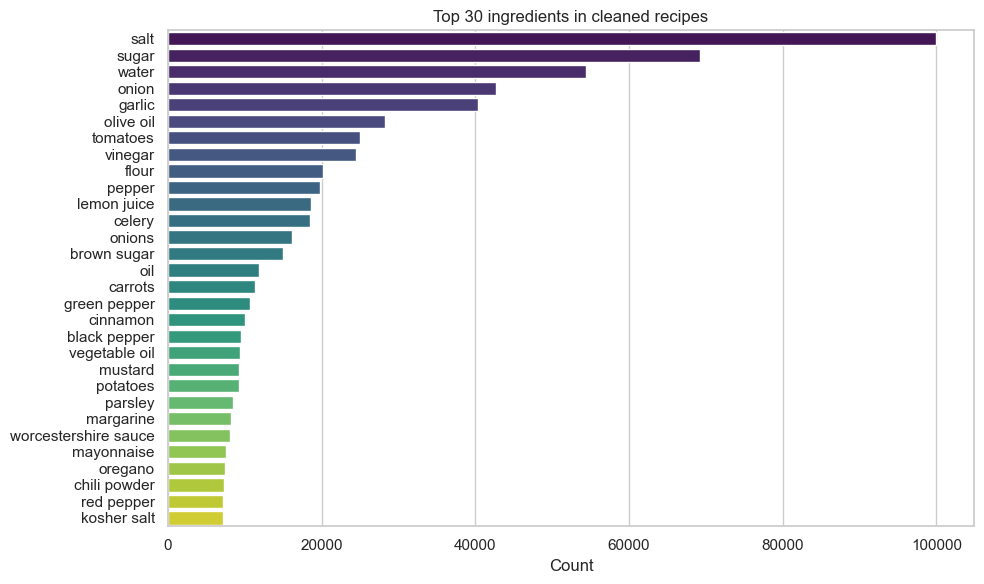

In [13]:
# Visualize the most common ingredients in the cleaned set
all_ings = Counter()
for ings in df_clean['ner_list']:
    all_ings.update(ings)
top_n = 30
most_common = all_ings.most_common(top_n)
if most_common:
    items, counts = zip(*most_common)
    plt.figure(figsize=(10,6))
    sns.barplot(x=list(counts), y=list(items), palette='viridis')
    plt.xlabel('Count')
    plt.title(f'Top {top_n} ingredients in cleaned recipes')
    plt.tight_layout()
    plt.show()
else:
    print('No ingredients found in cleaned set')

In [17]:
# Save cleaned DataFrame to processed CSV with structured ingredients and directions
out_fn = '..\\data\\processed\\processed_data.csv'
# ensure folder exists and save
import os
os.makedirs(os.path.dirname(out_fn), exist_ok=True)

# Select base columns we want to keep, now including NER if present
base_cols = ['title', 'ingredients', 'directions', 'n_ings']
if 'NER' in df_clean.columns:
    base_cols.append('NER')
df_clean_to_save = df_clean[base_cols].copy()

def parse_cooking_step(step):
    step = str(step).strip().lower()
    result = {
        "original": step,
        "time_minutes": None,
        "temperature_f": None,
        "step_text": step
    }
    # Extract cooking times (minutes)
    time_pattern = r'(\d+)\s*(?:minute|minutes|min|mins|hour|hours|hr|hrs)'
    time_match = re.search(time_pattern, step)
    if time_match:
        time_val = float(time_match.group(1))
        if 'hour' in time_match.group(0):
            time_val *= 60
        result["time_minutes"] = time_val
    # Extract temperatures (Fahrenheit)
    temp_pattern = r'(\d+)\s*(?:°|degrees|degree|deg|f\b|fahrenheit)'
    temp_match = re.search(temp_pattern, step)
    if temp_match:
        result["temperature_f"] = float(temp_match.group(1))
    return result

def structure_recipe_steps(directions_list):
    if isinstance(directions_list, str):
        directions_list = safe_literal_eval(directions_list)
    return [parse_cooking_step(step) for step in directions_list]

def structure_recipe_ingredients(ingredients_list):
    if isinstance(ingredients_list, str):
        ingredients_list = safe_literal_eval(ingredients_list)
    return [parse_ingredient(ing) for ing in ingredients_list]

# Add structured data
df_clean_to_save['structured_ingredients'] = df_clean_to_save['ingredients'].apply(structure_recipe_ingredients)
df_clean_to_save['structured_directions'] = df_clean_to_save['directions'].apply(structure_recipe_steps)

def sum_recipe_times(steps):
    times = [step["time_minutes"] for step in steps if step["time_minutes"] is not None]
    return sum(times) if times else None

def max_recipe_temp(steps):
    temps = [step["temperature_f"] for step in steps if step["temperature_f"] is not None]
    return max(temps) if temps else None

df_clean_to_save['total_time_minutes'] = df_clean_to_save['structured_directions'].apply(sum_recipe_times)
df_clean_to_save['cooking_temp_f'] = df_clean_to_save['structured_directions'].apply(max_recipe_temp)

# Define priority tiers based on keywords
tier1_keywords = [
    'soup', 'stew', 'chili', 'casserole', 'one pot', 'one-pot', 'rice', 'pasta', 'bean', 'lentil',
    'oatmeal', 'breakfast', 'curry', 'jambalaya', 'pilaf'
]
tier2_keywords = [
    'bread', 'biscuit', 'roll', 'bake', 'vegetable', 'slow cooker', 'crock pot', 'crockpot'
]
tier3_keywords = [
    'cookie', 'brownie', 'dessert', 'snack', 'salad'
]

def get_recipe_tier(title, ingredients, directions):
    text = ' '.join([str(title), ' '.join(ingredients), ' '.join(directions)]).lower()
    for kw in tier1_keywords:
        if kw in text:
            return 1
    for kw in tier2_keywords:
        if kw in text:
            return 2
    for kw in tier3_keywords:
        if kw in text:
            return 3
    return 4

df_clean_to_save['tier'] = df_clean_to_save.apply(
    lambda x: get_recipe_tier(x['title'], 
                            safe_literal_eval(x['ingredients']), 
                            safe_literal_eval(x['directions'])),
    axis=1
)

TOTAL_RECIPES = 500
TIER1_FRACTION = 0.75
TIER2_FRACTION = 0.20
TIER3_FRACTION = 0.05

tier1_count = int(TOTAL_RECIPES * TIER1_FRACTION)
tier2_count = int(TOTAL_RECIPES * TIER2_FRACTION)
tier3_count = int(TOTAL_RECIPES * TIER3_FRACTION)
tier1_count += TOTAL_RECIPES - (tier1_count + tier2_count + tier3_count)

tier1_recipes = df_clean_to_save[df_clean_to_save['tier'] == 1].sample(n=min(tier1_count, len(df_clean_to_save[df_clean_to_save['tier'] == 1])))
tier2_recipes = df_clean_to_save[df_clean_to_save['tier'] == 2].sample(n=min(tier2_count, len(df_clean_to_save[df_clean_to_save['tier'] == 2])))
tier3_recipes = df_clean_to_save[df_clean_to_save['tier'] == 3].sample(n=min(tier3_count, len(df_clean_to_save[df_clean_to_save['tier'] == 3])))

df_final = pd.concat([tier1_recipes, tier2_recipes, tier3_recipes])

# Convert structured data to JSON strings for CSV storage
df_final['structured_ingredients'] = df_final['structured_ingredients'].apply(json.dumps)
df_final['structured_directions'] = df_final['structured_directions'].apply(json.dumps)

# Save DataFrame
df_final.to_csv(out_fn, index=False)
print('Saved cleaned data to', out_fn, 'with', len(df_final), 'rows')
print('\nRecipe distribution:')
print(f'Tier 1 (High Priority): {len(tier1_recipes)} recipes ({len(tier1_recipes)/len(df_final)*100:.1f}%)')
print(f'Tier 2 (Medium Priority): {len(tier2_recipes)} recipes ({len(tier2_recipes)/len(df_final)*100:.1f}%)')
print(f'Tier 3 (Low Priority): {len(tier3_recipes)} recipes ({len(tier3_recipes)/len(df_final)*100:.1f}%)')
print('\nColumns kept:', list(df_final.columns))

# Show a preview of structured data for the first recipe
print('\nExample of structured data for first recipe:')
print('\nIngredients:')
first_ingredients = json.loads(df_final['structured_ingredients'].iloc[0])
print(json.dumps(first_ingredients, indent=2))
print('\nDirections:')
first_directions = json.loads(df_final['structured_directions'].iloc[0])
print(json.dumps(first_directions, indent=2))
print(f'\nTotal Time: {df_final["total_time_minutes"].iloc[0]} minutes')
print(f'Cooking Temperature: {df_final["cooking_temp_f"].iloc[0]}°F')


Saved cleaned data to ..\data\processed\processed_data.csv with 500 rows

Recipe distribution:
Tier 1 (High Priority): 375 recipes (75.0%)
Tier 2 (Medium Priority): 100 recipes (20.0%)
Tier 3 (Low Priority): 25 recipes (5.0%)

Columns kept: ['title', 'ingredients', 'directions', 'n_ings', 'NER', 'structured_ingredients', 'structured_directions', 'total_time_minutes', 'cooking_temp_f', 'tier']

Example of structured data for first recipe:

Ingredients:
[
  {
    "original": "1 lb. ground turkey",
    "amount": 1.0,
    "raw_amount": "1",
    "unit": "g",
    "ingredient": "round turkey"
  },
  {
    "original": "1 large green pepper, chopped",
    "amount": 1.0,
    "raw_amount": "1",
    "unit": null,
    "ingredient": "arge green pepper, chopped"
  },
  {
    "original": "1 large onion, chopped",
    "amount": 1.0,
    "raw_amount": "1",
    "unit": null,
    "ingredient": "arge onion, chopped"
  },
  {
    "original": "1 or 2 stalks celery, chopped",
    "amount": 1.0,
    "raw_amoun

## Notes and next steps
- The cleaning rules use substring matching on normalized ingredient tokens; you may want to refine these with regex or token matching for fewer false positives.
- If you'd like to allow eggs or certain dairy items (e.g., powdered milk), move them out of `perishable_keywords`.
- Consider adding a small unit test that asserts the cleaned dataset contains only allowed staples and acceptable ingredient counts.